<a href="https://colab.research.google.com/github/MGuidolini/PUC-MVP/blob/main/MVP_Analise_de_Dados_e_Boas_pr%C3%A1ticas2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas OK

**Nome:** Marcos Aurélio Guidolini

**Matrícula:** 4052025002325

**Dataset Alimentos:** [Alimentos Dataset](https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/dados_alimentares_com_calorias.csv)

**Dataset Calorias:** [Calorias Dataset](https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/calorie_dataset.csv)


**---OBSERVAÇÕES IMPORTANTES---**

 Encorajamos você a usar a estrutura base deste Notebook para a construção das suas análises, já que ela contempla grande parte das sugestões do checklist no enunciado do MVP. Contudo, vale ressaltar que é necessário realizar mais etapas e análises, além das apresentadas neste notebook. É fundamental ter profundidade nas discussões e análises propostas, construindo um storytelling cativante que explore os principais conceitos e técnicas vistos nas aulas de Análise de Dados e Boas Práticas. **Este bloco de comentário com essas observações deve ser removido do seu projeto final**.

 **------**

# Descrição do Problema OK

O conjunto de dados de alimentos é um conjunto de dados variado que consiste em consumo de alimentação por individuo que é dividido por estado, faixa etária, sexo em um perído de tempo. O objetivo principal é classificar os alimentos em tipo de refeição, grupo alimentar, alimentos específico, quantidade ingerida do alimento e as calorias em cada refeição por indivíduo em cada estado.


## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?**

2. **Existe uma correlação entre comprimento da pétala e largura da pétala?**

3. **A espécie Iris setosa é mais facilmente separável das outras duas espécies?**

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características (comprimento e largura da sépala, comprimento e largura da pétala), o objetivo é prever a qual das três classes (espécies de Íris) uma determinada flor pertence.

## Seleção de Dados

O dataset Iris é um conjunto de dados amplamente disponível e frequentemente incluído em bibliotecas de aprendizado de máquina, como *scikit-learn* no Python. Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

## Atributos do Dataset OK

O dataset Alimentos contém 1000 amostras, com números aleatórios de amostras para cada refeição. Possui nove atributos:

- ***Estados Brasileiros:*** Em siglas
- ***Idade:*** Idade da Pessoa
- ***Sexo:*** F, M, Outro
- ***Data:*** formato ISO YYYY-MM-DD
- ***Refeição:*** Café da manhã, Almoço, Jantar, Lanche
- ***Grupo de alimento:*** Carboidrato, Proteina, Gordura, fibra, açúcar
- ***Alimento específico:*** (coerente com o grupo)
- ***Quantidade ingerida:*** (0 a 100g) em cada Refeição
- ***Calorias:*** Ingeridas em cada Refeição (Carboidrato → 4 kcal/g, Proteina → 4 kcal/g, Gordura → 9 kcal/g, fibra → 2 kcal/g, açúcar → 4 kcal/g)



# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [49]:
# Carrega arquivo csv usando Pandas usando uma URL

# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/dados_alimentares_com_calorias.csv"


# Informa o cabeçalho das colunas
colunas_Alimentos = ['Estados_Brasileiros', 'idade', 'sexo', 'data', 'refeição', 'Grupo_de_alimento', 'alimento_especifico', 'Quantidade_Ingerida/g', 'Calorias']

# Lê o arquivo utilizando as colunas informadas
Alimentos = pd.read_csv(url, names=colunas_Alimentos, skiprows=1, delimiter=',')

# Pega apenas os dados do dataset e guardando em um array
array = Alimentos.values


# Separa o array em variáveis preditoras (X) e variável target (Y)
X = array[:,0:8]
Y = array[:,0:8]

# exibindo as últimas linhas
Alimentos.tail()
#Calorias.head()

,Estados_Brasileiros,idade,sexo,data,refeição,Grupo_de_alimento,alimento_especifico,Quantidade_Ingerida/g,Calorias
995,AC,52,M,2026-01-09,Jantar,fibra,brocolis,48,96
996,RN,27,Outro,2026-01-11,Almoco,fibra,aveia,63,126
997,SE,36,M,2026-01-30,Lanche,Proteina,frango,47,188
998,PE,56,F,2025-09-28,Jantar,Carboidrato,mandioca,44,176
999,DF,21,F,2025-10-10,Almoco,Carboidrato,arroz,97,388


In [48]:
# Carrega arquivo csv usando Pandas usando uma URL

# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/calorie_dataset.csv"



# Informa o cabeçalho das colunas
colunas_Calorias = ['protein_g', 'carbs_g', 'fat_g', 'fiber_g', 'sugar_g', 'calories', 'calorie_class']


# Lê o arquivo utilizando as colunas informadas
Calorias = pd.read_csv(url, names=colunas_Calorias, skiprows=1, delimiter=',')

# Pega apenas os dados do dataset e guardando em um array
array = Calorias.values


# Separa o array em variáveis preditoras (X) e variável target (Y)
X = array[:,0:8]
Y = array[:,0:8]

# exibindo as últimas linhas
Calorias.tail()
#Calorias.head()

,protein_g,carbs_g,fat_g,fiber_g,sugar_g,calories,calorie_class
4995,54.5,54.1,20.0,9.1,11.8,592.0,medium
4996,18.2,67.0,25.1,6.4,13.9,542.0,medium
4997,14.2,49.8,28.9,2.1,0.1,519.0,medium
4998,22.0,20.5,28.3,13.9,13.4,444.0,medium
4999,33.6,36.6,17.6,3.7,27.5,433.0,medium


In [38]:
# guardo o dataset em um dataframe
dafr_Alimentos = pd.DataFrame(data=Alimentos, columns=colunas)
#df['species'] = iris.target_names[iris.target]

In [ ]:
# guardo o dataset em um dataframe
dafr_Calorias = pd.DataFrame(data=Calorias, columns=colunas)
#df['species'] = iris.target_names[iris.target]

In [39]:
# primeiras linhas
dafr.head()

,Estados_Brasileiros,idade,sexo,data,refeição,Grupo_de_alimento,alimento_especifico,Quantidade_Ingerida/g,Calorias
0,MS,56,Outro,2025-11-21,Cafe da manha,fibra,chia,30,60
1,SC,79,Outro,2026-03-13,Jantar,acucar,refrigerante,100,400
2,SP,22,F,2026-02-16,Almoco,Proteina,frango,73,292
3,MA,55,Outro,2026-01-04,Almoco,fibra,couve,1,2
4,RO,28,M,2026-01-22,Almoco,acucar,biscoito,38,152


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Iris, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Iris possui 150 instâncias (observações), com 50 instâncias para cada uma das três espécies. As quatro características de medição são de tipo numérico (float), enquanto o atributo 'species' é categórico.

In [40]:
print(f"Total de instâncias: {len(dafr)}")
print("\nTipos de dados por coluna:")
print(dafr.info())

Total de instâncias: 1000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Estados_Brasileiros    1000 non-null   object
 1   idade                  1000 non-null   int64 
 2   sexo                   1000 non-null   object
 3   data                   1000 non-null   object
 4   refeição               1000 non-null   object
 5   Grupo_de_alimento      1000 non-null   object
 6   alimento_especifico    1000 non-null   object
 7   Quantidade_Ingerida/g  1000 non-null   int64 
 8   Calorias               1000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 70.4+ KB
None


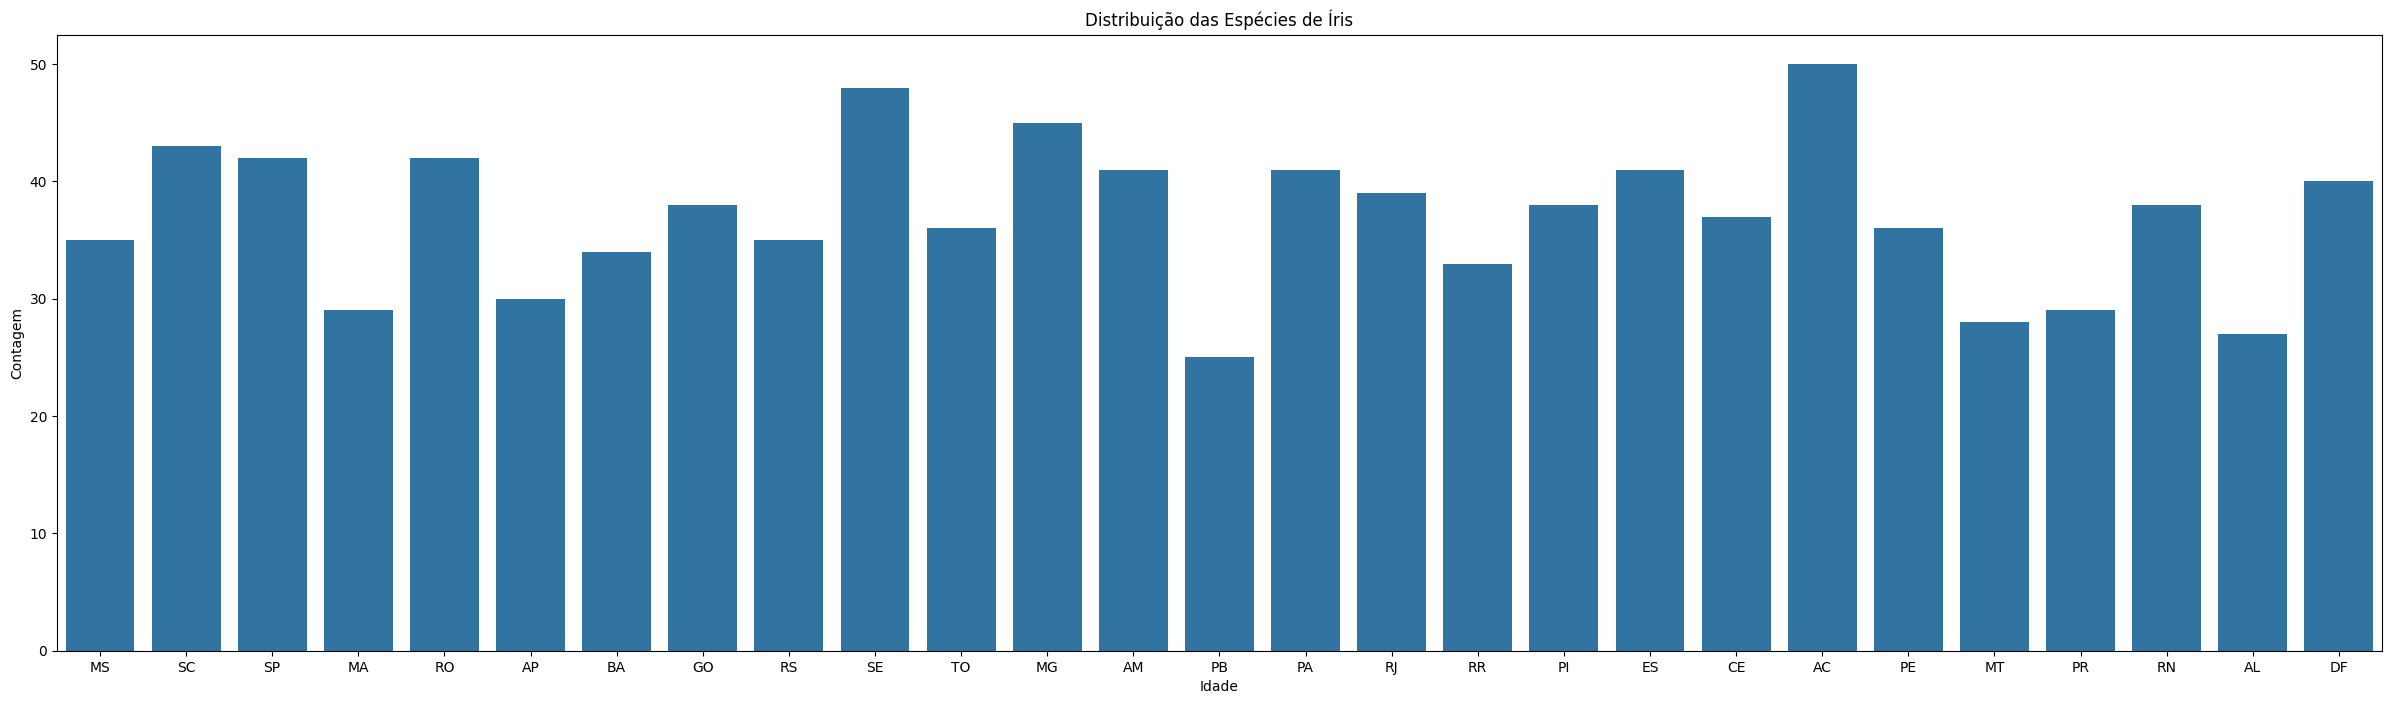

In [41]:
plt.figure(figsize=(30, 8))
# gráfico de barras simples
sns.countplot(x='Estados_Brasileiros', data=dafr)
plt.title('Distribuição das Espécies de Íris')
plt.xlabel('Idade')
plt.ylabel('Contagem')
plt.show()

In [42]:
print(f"Total de instâncias: {len(dafr)}")
print("\nTipos de dados por coluna:")
print(dafr.info())

Total de instâncias: 1000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Estados_Brasileiros    1000 non-null   object
 1   idade                  1000 non-null   int64 
 2   sexo                   1000 non-null   object
 3   data                   1000 non-null   object
 4   refeição               1000 non-null   object
 5   Grupo_de_alimento      1000 non-null   object
 6   alimento_especifico    1000 non-null   object
 7   Quantidade_Ingerida/g  1000 non-null   int64 
 8   Calorias               1000 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 70.4+ KB
None


O gráfico de barras mostra que cada espécie de Íris (setosa, versicolor, virginica) possui 50 amostras, confirmando que o dataset é balanceado em termos de classes.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [43]:
# estatísticas descritivas básicas do dataset
dafr.describe()

,idade,Quantidade_Ingerida/g,Calorias
count,1000.000000,1000.000000,1000.000000
mean,47.475000,50.106000,235.421000
std,18.293387,28.568635,193.833855
min,18.000000,0.000000,0.000000
25%,31.000000,26.750000,99.750000
50%,46.000000,51.000000,187.000000
75%,63.000000,73.250000,324.000000
max,80.000000,100.000000,900.000000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [33]:
# média dos atributos numéricos do dataset
dafr.describe().loc['mean']

,mean
idade,47.475
Quantidade_Ingerida/g,50.106
Calorias,235.421


In [ ]:
# Qual gráfico seria interessante usar pra mostrar a média?

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
dafr.describe().loc['std']

,std
Proteinas/g,9.907564
Carboidratos/g,20.071407
Gordura/g,7.933298
Fibra/g,3.923217
Açucar/g,9.298863
Calorias,117.948845


In [ ]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *sepal length*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

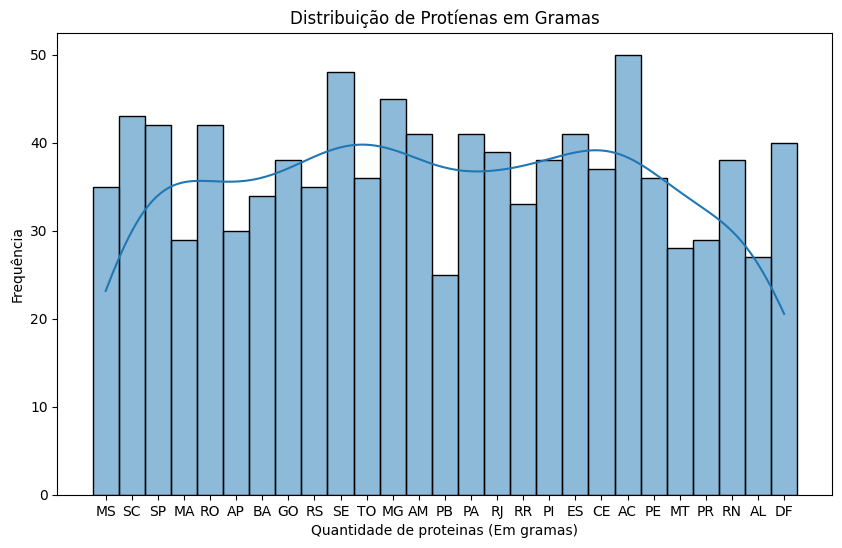

In [45]:
plt.figure(figsize=(10, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr['Estados_Brasileiros'], kde=True)
plt.title('Distribuição de Protíenas em Gramas')
plt.xlabel('Quantidade de proteinas (Em gramas)')
plt.ylabel('Frequência')
plt.show()

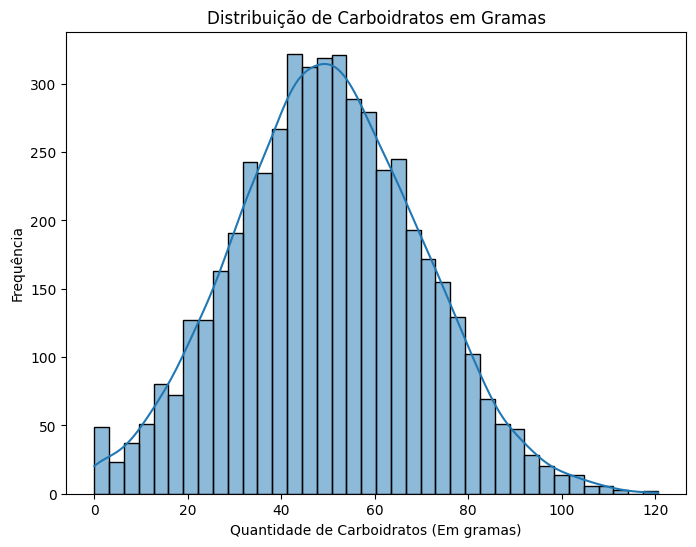

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr['Carboidratos/g'], kde=True)
plt.title('Distribuição de Carboidratos em Gramas')
plt.xlabel('Quantidade de Carboidratos (Em gramas)')
plt.ylabel('Frequência')
plt.show()

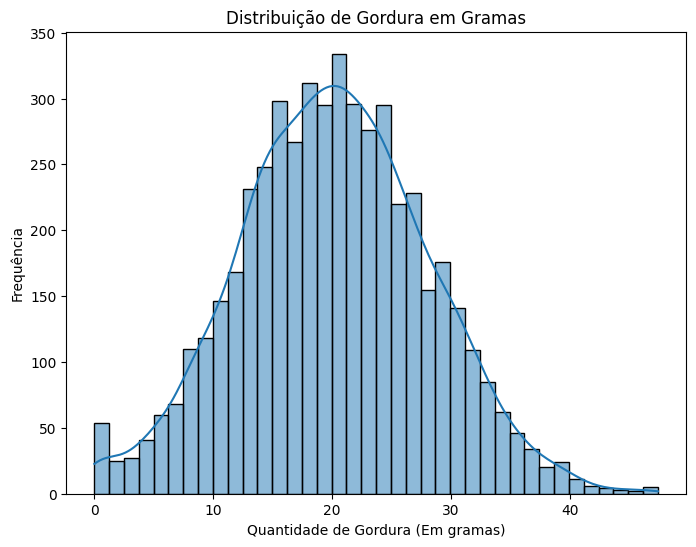

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr['Gordura/g'], kde=True)
plt.title('Distribuição de Gordura em Gramas')
plt.xlabel('Quantidade de Gordura (Em gramas)')
plt.ylabel('Frequência')
plt.show()

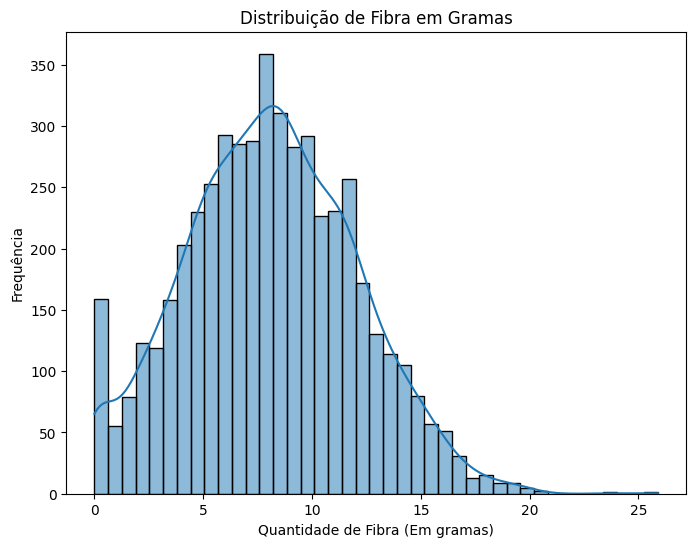

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr['Fibra/g'], kde=True)
plt.title('Distribuição de Fibra em Gramas')
plt.xlabel('Quantidade de Fibra (Em gramas)')
plt.ylabel('Frequência')
plt.show()

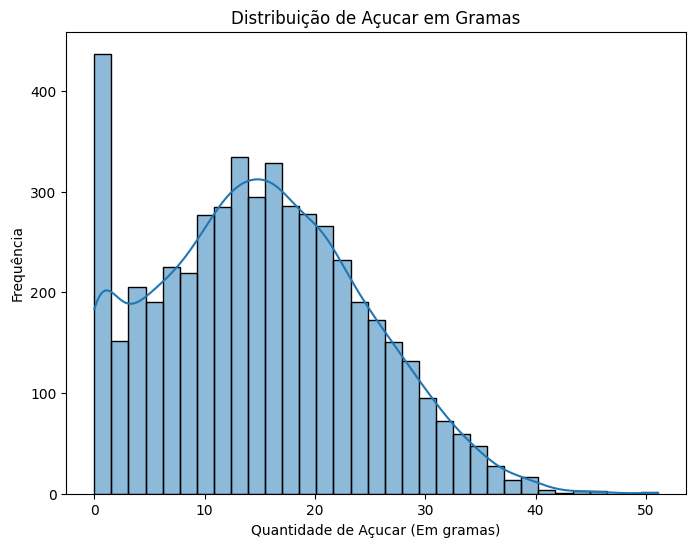

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr['Açucar/g'], kde=True)
plt.title('Distribuição de Açucar em Gramas')
plt.xlabel('Quantidade de Açucar (Em gramas)')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição do comprimento da sépala. A curva de densidade estimada (KDE) nos indica que a distribuição parece bimodal ou multimodal, indicando que as espécies podem ter comprimentos de sépalas diferentes.

### *sepal width*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(df['sepal width (cm)'], kde=True)
plt.title('Distribuição da Largura da Sépala')
plt.xlabel('Largura da Sépala (cm)')
plt.ylabel('Frequência')
plt.show()

Quais impressões você tem sobre a distribuição do atributo 'sepal width'?

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
dafr.groupby('Classes_Calorica').describe()

Proteinas/g                                                  \
                       count       mean       std  min     25%   50%     75%   
Classes_Calorica                                                               
high                   163.0  31.935583  8.595546  9.4  25.450  32.0  37.200   
low                   1248.0  21.020994  9.421050  0.0  14.475  21.3  27.325   
medium                3589.0  26.175508  9.670193  0.0  19.500  26.3  32.600   

                       Carboidratos/g             ... Açucar/g       Calorias  \
                   max          count       mean  ...      75%   max    count   
Classes_Calorica                                  ...                           
high              56.4          163.0  80.871166  ...    23.75  44.3    163.0   
low               56.1         1248.0  32.467708  ...    21.40  51.1   1248.0   
medium            64.3         3589.0  54.486041  ...    21.30  51.0   3589.0   

                                                                            
                        mean        std    min    25%    50%    75%    max  
Classes_Calorica                                                            
high              742.638037  43.325757  700.0  713.5  729.0  753.5  975.0  
low               331.254006  57.040444   56.0  302.0  347.0  377.0  400.0  
medium            520.430203  75.519102  400.0  457.0  512.0  576.0  700.0  

[3 rows x 48 columns]

### *petal length* por Espécie


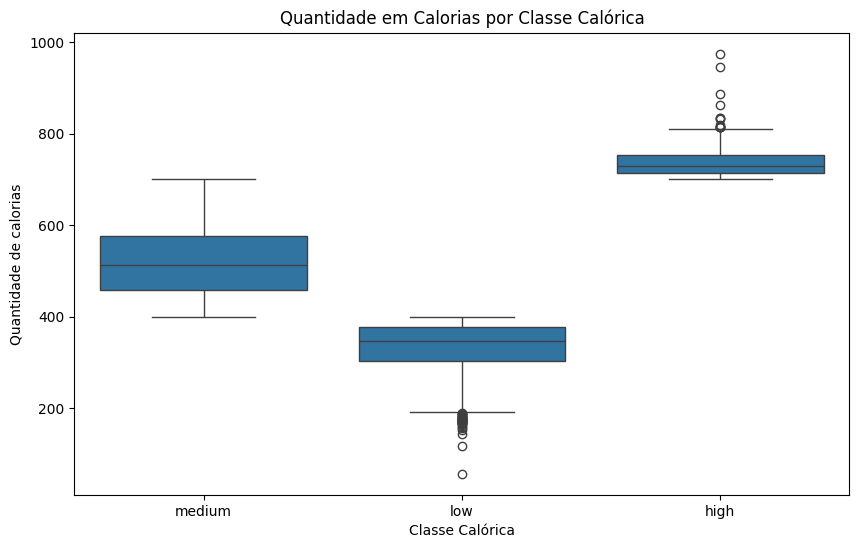

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Calorias', data=dafr)
plt.title('Quantidade em Calorias por Classe Calórica')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade de calorias')
plt.show()

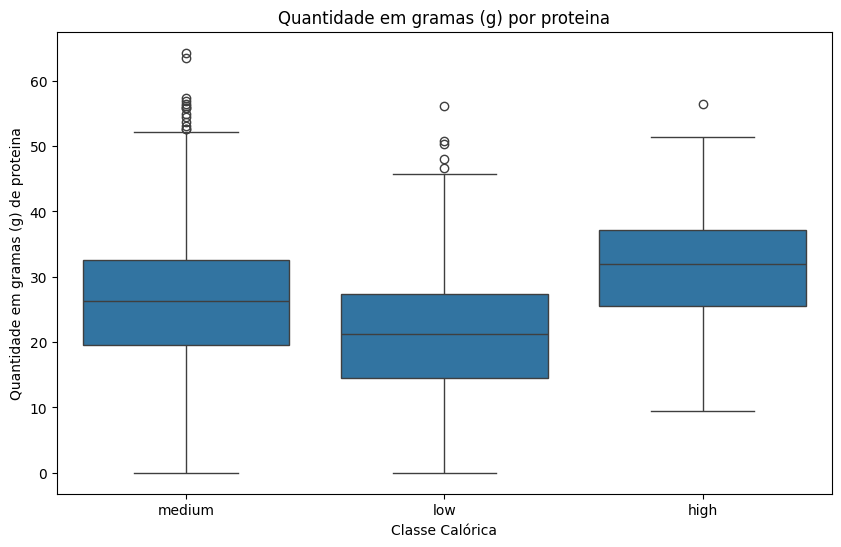

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Proteinas/g', data=dafr)
plt.title('Quantidade em gramas (g) por proteina')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de proteina')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

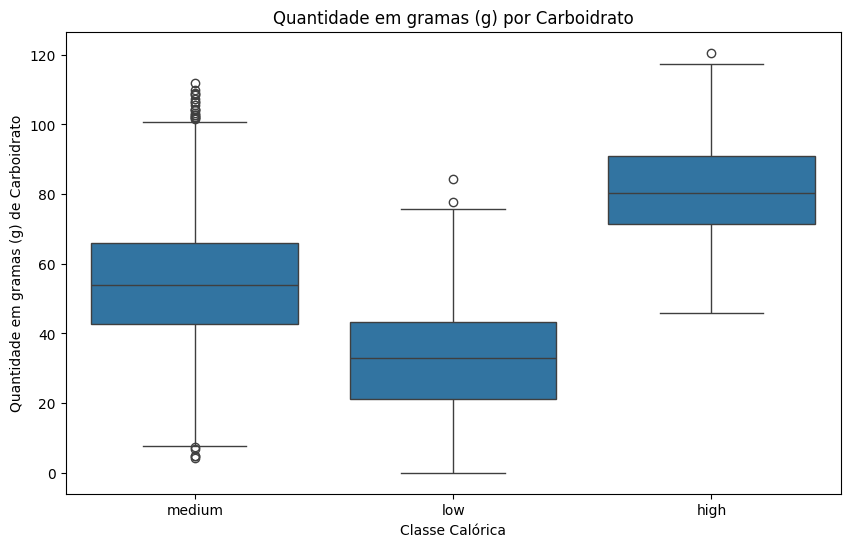

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Carboidratos/g', data=dafr)
plt.title('Quantidade em gramas (g) por Carboidrato')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Carboidrato')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

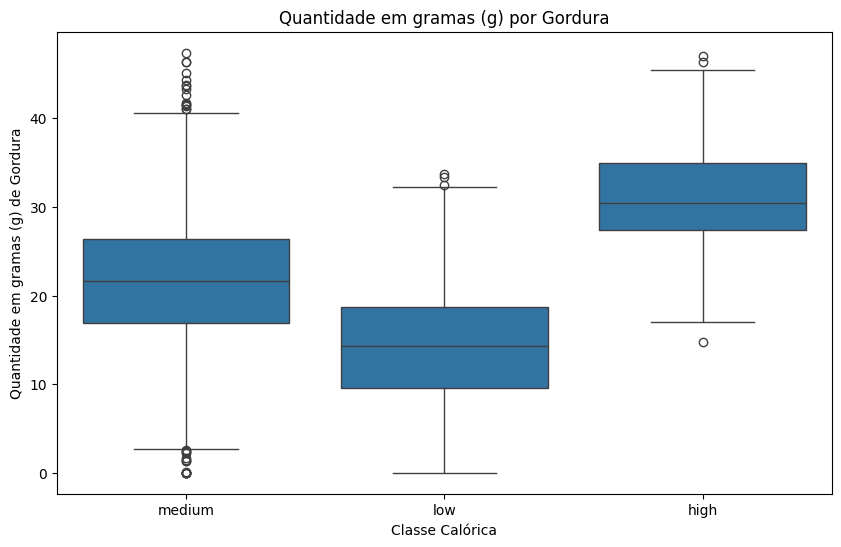

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Gordura/g', data=dafr)
plt.title('Quantidade em gramas (g) por Gordura')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Gordura')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

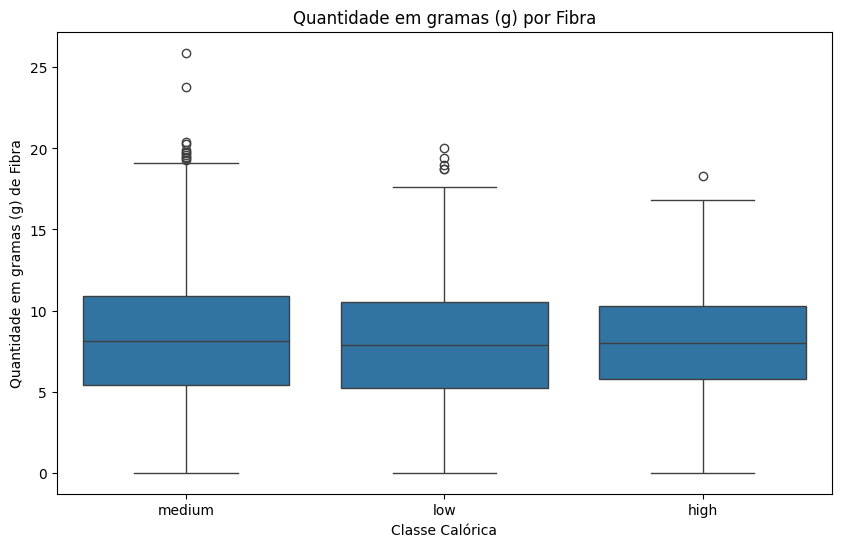

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Fibra/g', data=dafr)
plt.title('Quantidade em gramas (g) por Fibra')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Fibra')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

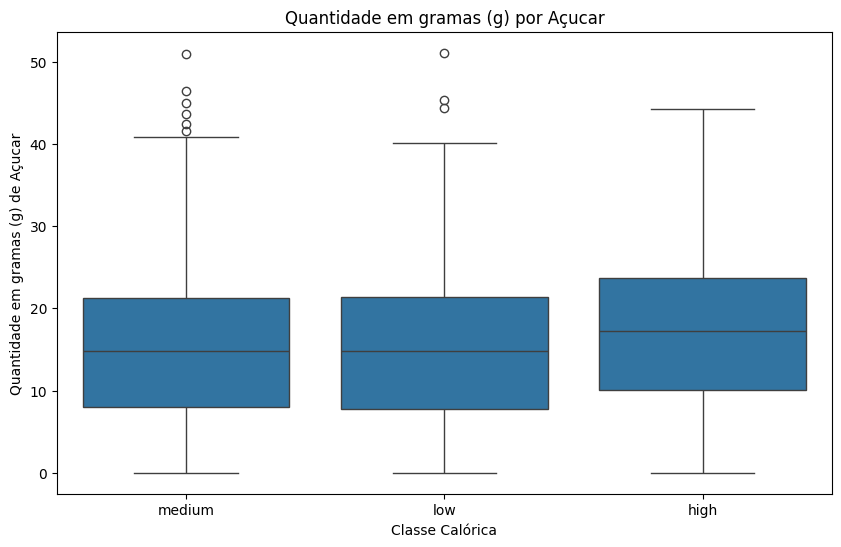

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Açucar/g', data=dafr)
plt.title('Quantidade em gramas (g) por Açucar')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Açucar')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

### *petal width* por Espécie

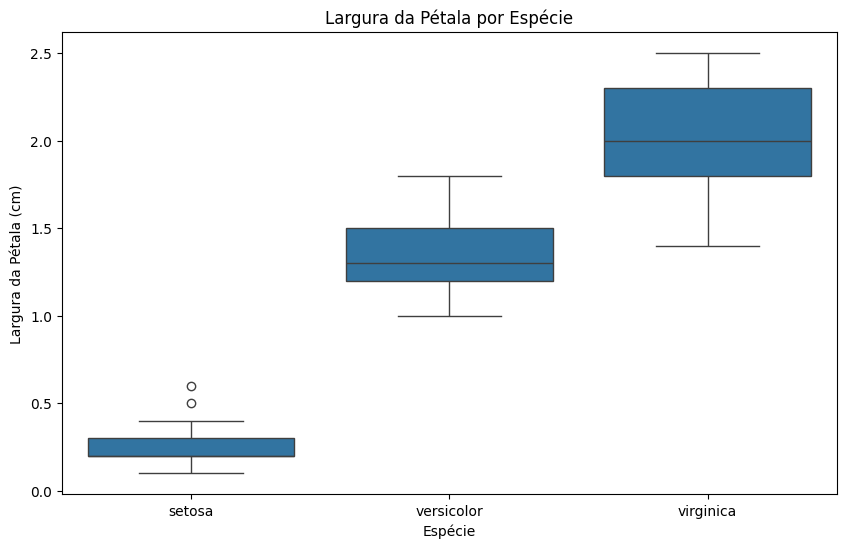

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal width (cm)', data=df)
plt.title('Largura da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Largura da Pétala (cm)')
plt.show()

Quais impressões o boxplot trouxe?

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
dafr.iloc[:, :4].corr()


Matriz de Correlação:


,Proteinas/g,Carboidratos/g,Gordura/g,Fibra/g
Proteinas/g,1.000000,-0.002738,-0.001996,0.002640
Carboidratos/g,-0.002738,1.000000,-0.006142,-0.014636
Gordura/g,-0.001996,-0.006142,1.000000,0.012373
Fibra/g,0.002640,-0.014636,0.012373,1.000000


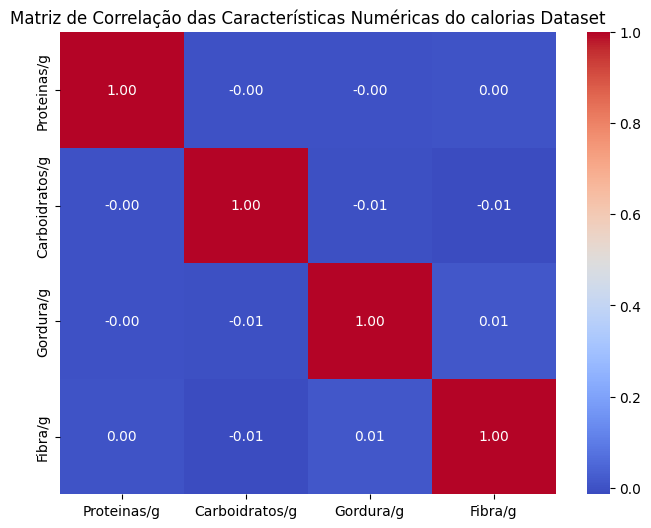

In [ ]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(dafr.iloc[:, :4].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do calorias Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
dafr.isnull().sum()

Valores nulos no dataset Iris:


,0
Proteinas/g,0
Carboidratos/g,0
Gordura/g,0
Fibra/g,0
Açucar/g,0
Calorias,0
Classes_Calorica,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Separar features (X) e target (y)
X = dafr.drop('Classes_Calorica', axis=1)
y = dafr['Classes_Calorica']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (3500, 6)
Dimensões de X_test: (1500, 6)
Dimensões de y_train: (3500,)
Dimensões de y_test: (1500,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   Proteinas/g  Carboidratos/g  Gordura/g   Fibra/g  Açucar/g  Calorias
0     0.359253        0.587894   0.462025  0.316602  0.190196  0.540313
1     0.399689        0.331675   0.459916  0.320463  0.000000  0.404332
2     0.611198        0.071310   0.299578  0.471042  0.550980  0.168472
3     0.427683        0.388060   0.320675  0.386100  0.264706  0.351384
4     0.115086        0.383914   0.495781  0.370656  0.000000  0.368231


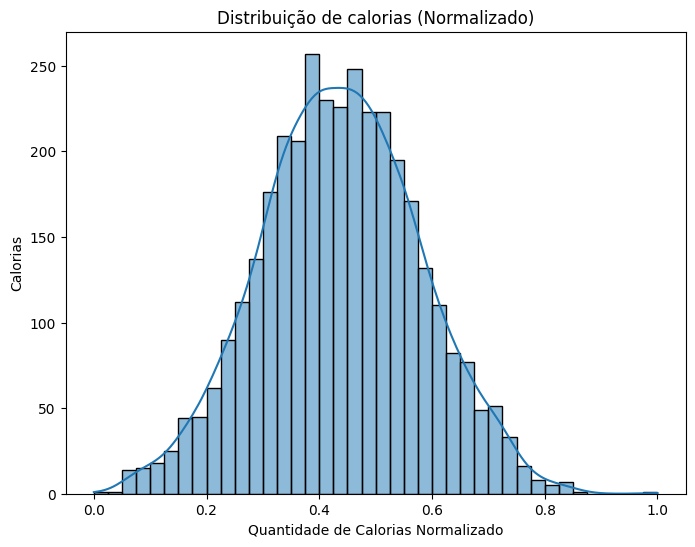

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Calorias'], kde=True)
plt.title('Distribuição de calorias (Normalizado)')
plt.xlabel('Quantidade de Calorias Normalizado')
plt.ylabel('Calorias')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

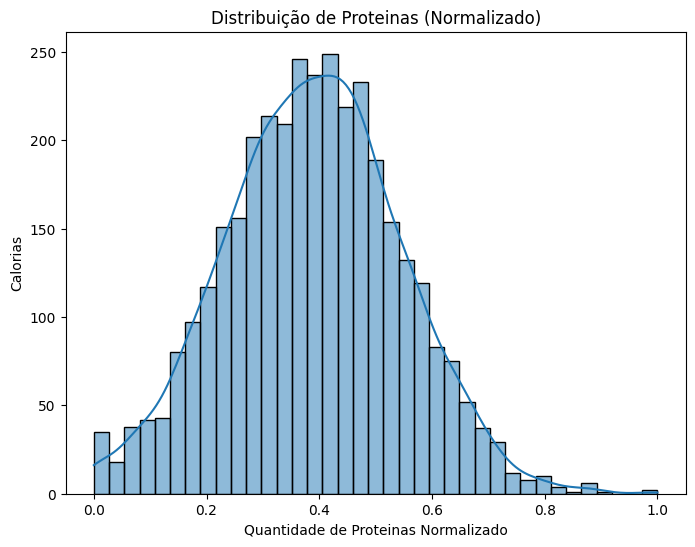

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Proteinas/g'], kde=True)
plt.title('Distribuição de Proteinas (Normalizado)')
plt.xlabel('Quantidade de Proteinas Normalizado')
plt.ylabel('Proteinas')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

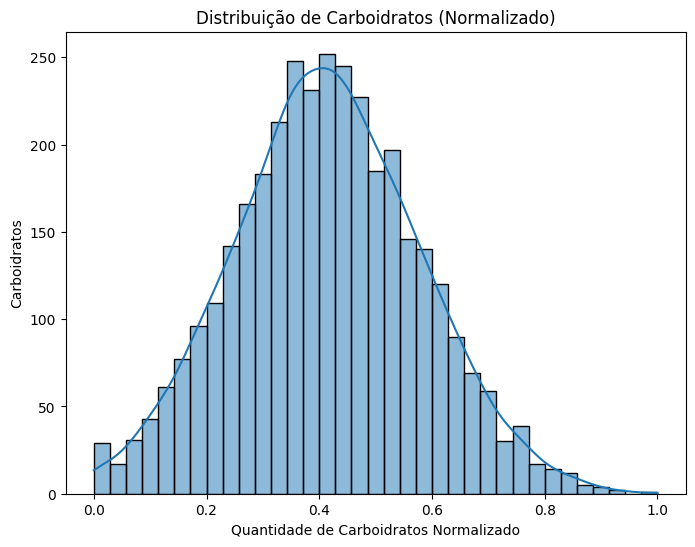

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Carboidratos/g'], kde=True)
plt.title('Distribuição de Carboidratos (Normalizado)')
plt.xlabel('Quantidade de Carboidratos Normalizado')
plt.ylabel('Carboidratos')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

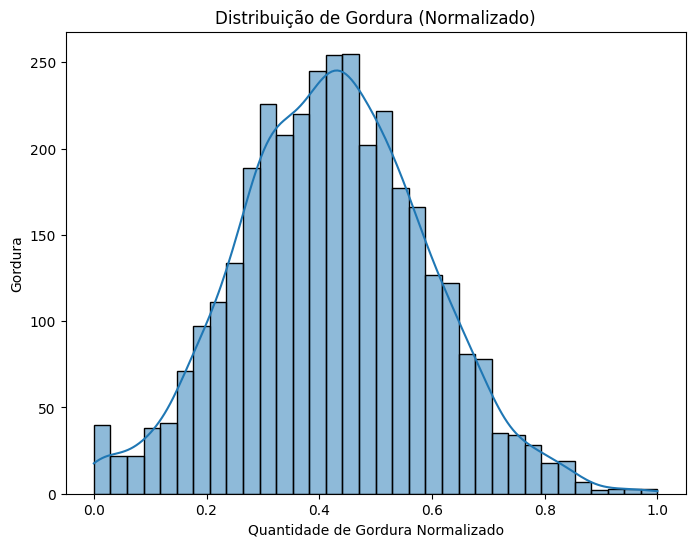

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Gordura/g'], kde=True)
plt.title('Distribuição de Gordura (Normalizado)')
plt.xlabel('Quantidade de Gordura Normalizado')
plt.ylabel('Gordura')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

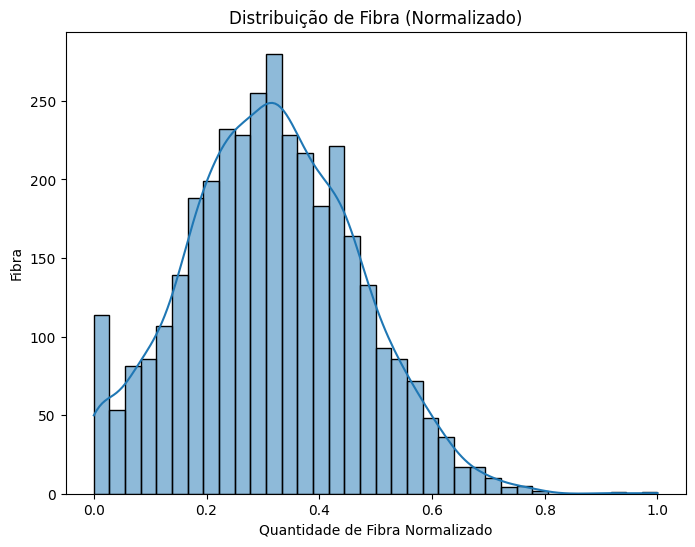

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Fibra/g'], kde=True)
plt.title('Distribuição de Fibra (Normalizado)')
plt.xlabel('Quantidade de Fibra Normalizado')
plt.ylabel('Fibra')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

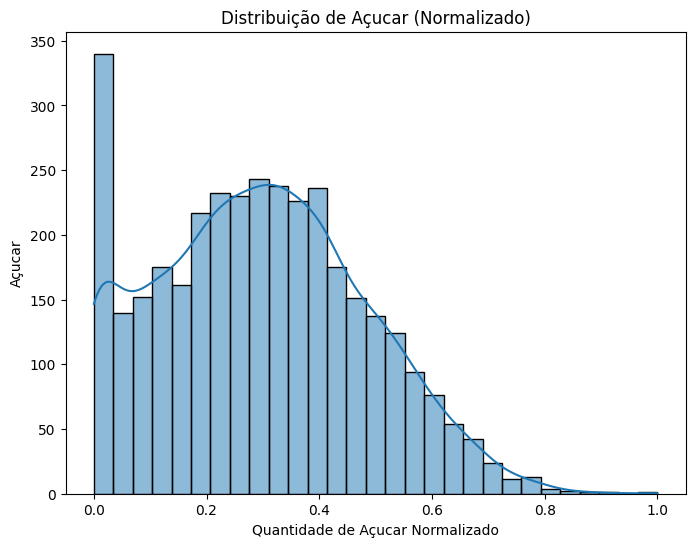

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Açucar/g'], kde=True)
plt.title('Distribuição de Açucar (Normalizado)')
plt.xlabel('Quantidade de Açucar Normalizado')
plt.ylabel('Açucar')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
   Proteinas/g  Carboidratos/g  Gordura/g   Fibra/g  Açucar/g  Calorias
0    -0.190099        1.061639   0.233419  0.013266 -0.567000  0.730150
1     0.070825       -0.495263   0.220754  0.038693 -1.600837 -0.236142
2     1.435663       -2.077358  -0.741815  1.030360  1.394094 -1.912188
3     0.251466       -0.152644  -0.615161  0.470958 -0.161991 -0.612397
4    -1.765684       -0.177837   0.436065  0.369249 -1.600837 -0.492680


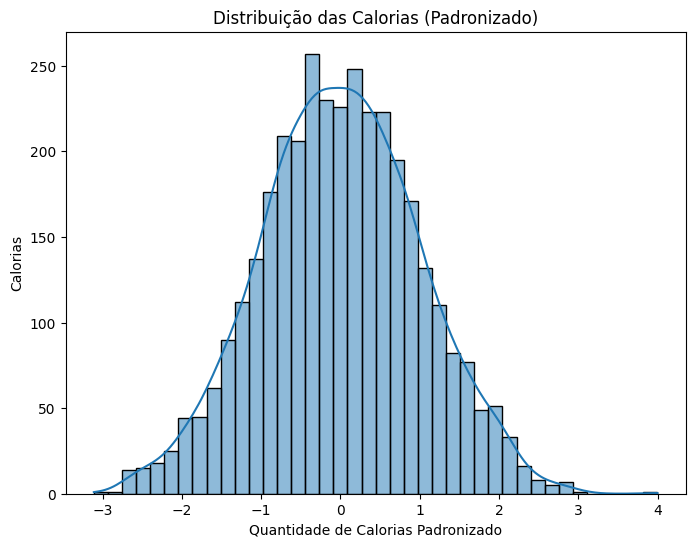

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Calorias'], kde=True)
plt.title('Distribuição das Calorias (Padronizado)')
plt.xlabel('Quantidade de Calorias Padronizado')
plt.ylabel('Calorias')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

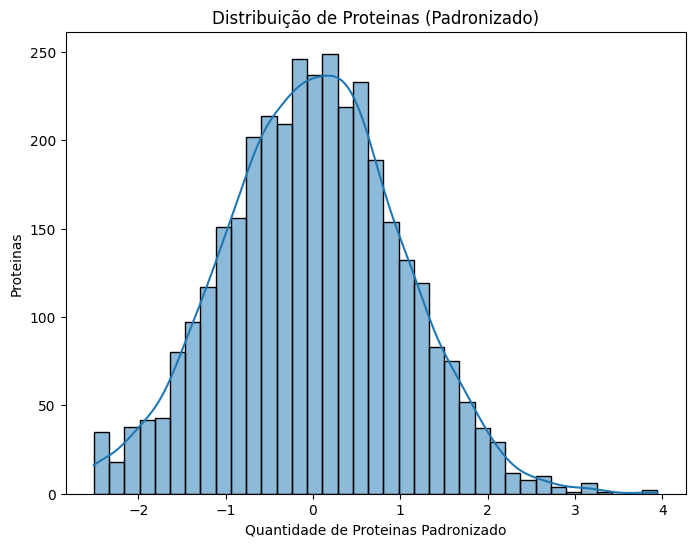

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Proteinas/g'], kde=True)
plt.title('Distribuição de Proteinas (Padronizado)')
plt.xlabel('Quantidade de Proteinas Padronizado')
plt.ylabel('Proteinas')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

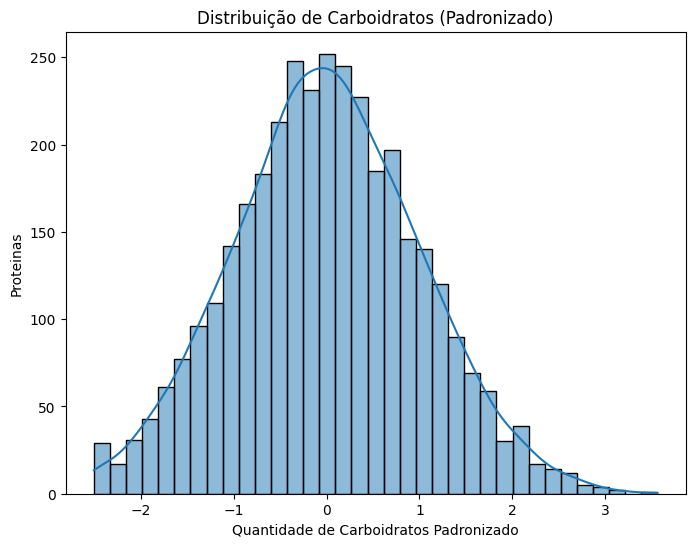

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Carboidratos/g'], kde=True)
plt.title('Distribuição de Carboidratos (Padronizado)')
plt.xlabel('Quantidade de Carboidratos Padronizado')
plt.ylabel('Proteinas')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

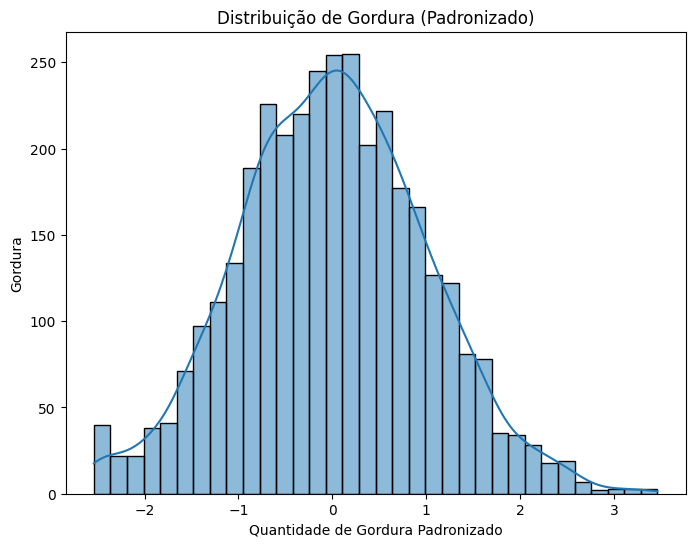

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Gordura/g'], kde=True)
plt.title('Distribuição de Gordura (Padronizado)')
plt.xlabel('Quantidade de Gordura Padronizado')
plt.ylabel('Gordura')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

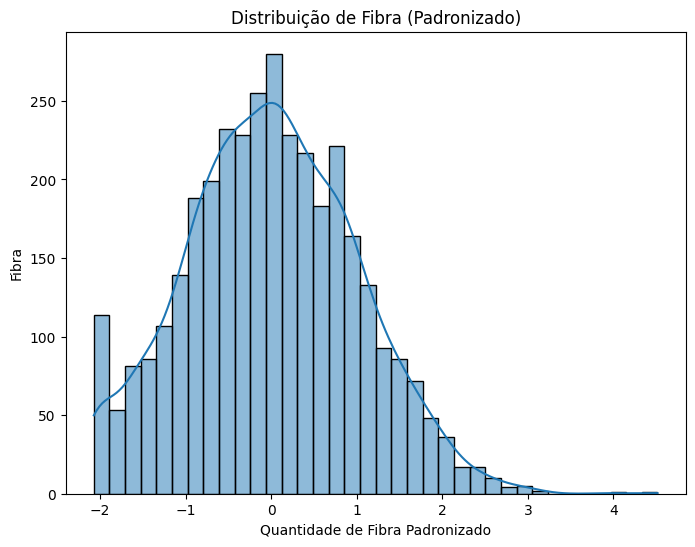

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Fibra/g'], kde=True)
plt.title('Distribuição de Fibra (Padronizado)')
plt.xlabel('Quantidade de Fibra Padronizado')
plt.ylabel('Fibra')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

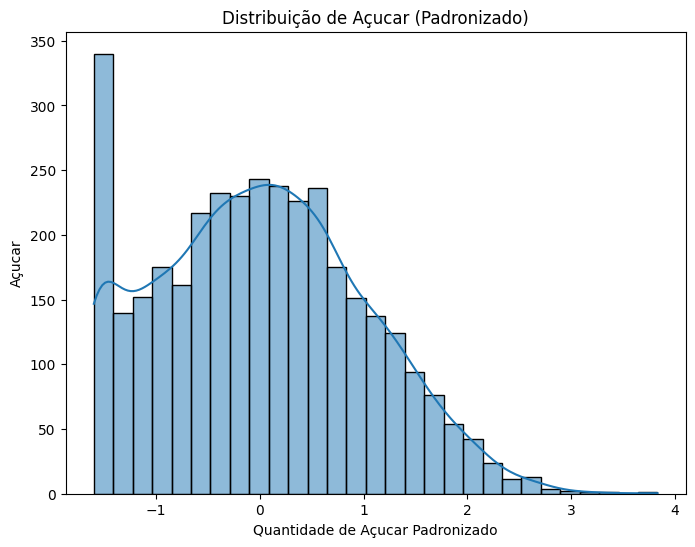

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Açucar/g'], kde=True)
plt.title('Distribuição de Açucar (Padronizado)')
plt.xlabel('Quantidade de Açucar Padronizado')
plt.ylabel('Açucar')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:
# hipótese 1

## Hipótese 2

In [ ]:
# hipótese 2

## Hipótese 3

In [ ]:
# hipótese 3

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.